# Data cleansing

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
df=pd.read_csv("insurance_claims.csv")


In [4]:
# drop column as 100% nan-values
df.drop('_c39', axis=1,inplace= True)

In [5]:
#change to datetime
df["policy_bind_date"]=pd.to_datetime(df['policy_bind_date'])
df["incident_date"]=pd.to_datetime(df['incident_date'])
df[['policy_bind_date', 'incident_date']].dtypes

policy_bind_date    datetime64[ns]
incident_date       datetime64[ns]
dtype: object

In [6]:
#additional columns year, month, date of policy bind date
df['policy_bind_year']=df["policy_bind_date"].dt.year
df['policy_bind_month']=df["policy_bind_date"].dt.month
df['policy_bind_weekday']=df["policy_bind_date"].dt.weekday

In [7]:
#additional columns month, date of incident date as year is 2015 for all cases
df['incident_month']=df["incident_date"].dt.month
df['incident_weekday']=df["incident_date"].dt.weekday

In [8]:
#ensure consistency on column names
rename ={'capital-gains':'capital_gains','capital-loss': 'capital_loss'}
df.rename(columns=rename, inplace=True)

In [9]:
cat_vars = df[['authorities_contacted', 'auto_make', 'auto_model', 'collision_type', 'incident_city', 'incident_location', 
               'incident_severity', 'incident_state', 'incident_hour_of_the_day', 'incident_type',
               'insured_education_level', 'insured_hobbies', 'insured_occupation', 
               'insured_relationship', 'insured_sex', 'insured_zip', 
               'police_report_available', 'policy_csl', 'policy_deductable', 
               'policy_state', 'property_damage']]


cat_vars

,authorities_contacted,auto_make,auto_model,collision_type,incident_city,incident_location,incident_severity,incident_state,incident_hour_of_the_day,incident_type,...,insured_hobbies,insured_occupation,insured_relationship,insured_sex,insured_zip,police_report_available,policy_csl,policy_deductable,policy_state,property_damage
0,Police,Saab,92x,Side Collision,Columbus,9935 4th Drive,Major Damage,SC,5,Single Vehicle Collision,...,sleeping,craft-repair,husband,MALE,466132,YES,250/500,1000,OH,YES
1,Police,Mercedes,E400,?,Riverwood,6608 MLK Hwy,Minor Damage,VA,8,Vehicle Theft,...,reading,machine-op-inspct,other-relative,MALE,468176,?,250/500,2000,IN,?
2,Police,Dodge,RAM,Rear Collision,Columbus,7121 Francis Lane,Minor Damage,NY,7,Multi-vehicle Collision,...,board-games,sales,own-child,FEMALE,430632,NO,100/300,2000,OH,NO
3,Police,Chevrolet,Tahoe,Front Collision,Arlington,6956 Maple Drive,Major Damage,OH,5,Single Vehicle Collision,...,board-games,armed-forces,unmarried,FEMALE,608117,NO,250/500,2000,IL,?
4,NaN,Accura,RSX,?,Arlington,3041 3rd Ave,Minor Damage,NY,20,Vehicle Theft,...,board-games,sales,unmarried,MALE,610706,NO,500/1000,1000,IL,NO
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,Fire,Honda,Accord,Front Collision,Northbrook,6045 Andromedia St,Minor Damage,NC,20,Single Vehicle Collision,...,paintball,craft-repair,unmarried,FEMALE,431289,?,500/1000,1000,OH,YES
996,Fire,Volkswagen,Passat,Rear Collision,Northbend,3092 Texas Drive,Major Damage,SC,23,Single Vehicle Collision,...,sleeping,prof-specialty,wife,FEMALE,608177,?,100/300,1000,IL,YES
997,Police,Suburu,Impreza,Side Collision,Arlington,7629 5th St,Minor Damage,NC,4,Multi-vehicle Collision,...,bungie-jumping,armed-forces,other-relative,FEMALE,442797,YES,250/500,500,OH,?
998,Other,Audi,A5,Rear Collision,Arlington,6128 Elm Lane,Major Damage,NY,2,Single Vehicle Collision,...,base-jumping,handlers-cleaners,wife,MALE,441714,YES,500/1000,2000,IL,?


# Classes built for incident_location - nothing found

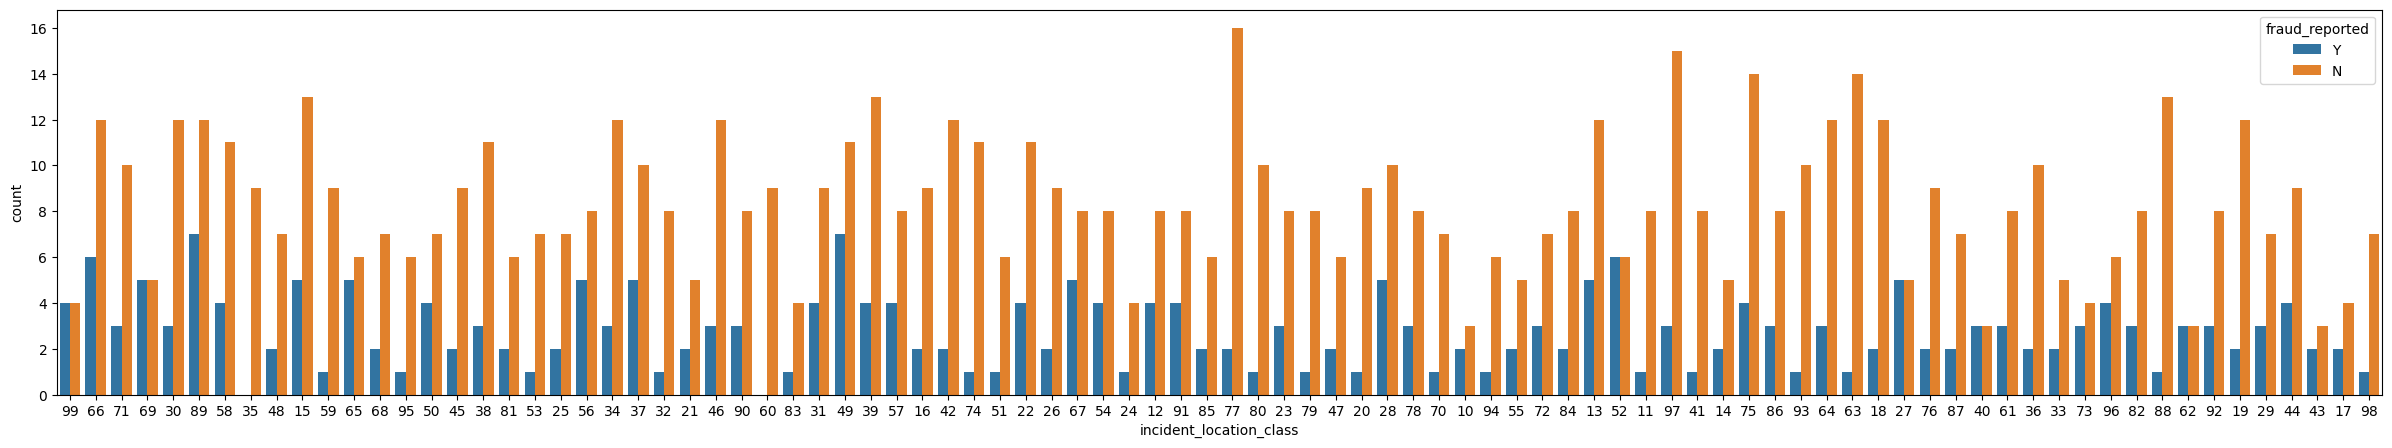

Chi2ContingencyResult(statistic=np.float64(68.89308719822739), pvalue=np.float64(0.9437846758662052), dof=89, expected_freq=array([[ 3.765,  1.235],
       [ 6.777,  2.223],
       [ 9.036,  2.964],
       [12.801,  4.199],
       [ 5.271,  1.729],
       [13.554,  4.446],
       [ 8.283,  2.717],
       [ 4.518,  1.482],
       [10.542,  3.458],
       [10.542,  3.458],
       [ 7.53 ,  2.47 ],
       [ 5.271,  1.729],
       [11.295,  3.705],
       [ 8.283,  2.717],
       [ 3.765,  1.235],
       [ 6.777,  2.223],
       [ 8.283,  2.717],
       [ 7.53 ,  2.47 ],
       [11.295,  3.705],
       [ 7.53 ,  2.47 ],
       [11.295,  3.705],
       [ 9.789,  3.211],
       [ 6.777,  2.223],
       [ 5.271,  1.729],
       [11.295,  3.705],
       [ 6.777,  2.223],
       [ 9.036,  2.964],
       [11.295,  3.705],
       [10.542,  3.458],
       [12.801,  4.199],
       [ 4.518,  1.482],
       [ 6.777,  2.223],
       [10.542,  3.458],
       [ 3.765,  1.235],
       [ 9.789,  3.211],
 

In [10]:
#analze incident location make classes starting with first two digits in column
df['incident_location_class']=df['incident_location'].str[:2]
df['incident_location_class'].value_counts()
# compare with fraud_reported
pd.crosstab(index=df['incident_location_class'], columns=df['fraud_reported'], normalize='index')
plt.figure(figsize=(30,5))
sns.countplot(x='incident_location_class', data=df, hue='fraud_reported')
plt.show()

# chi2 test for independence
from scipy.stats import chi2_contingency
chi2_contingency(pd.crosstab(index=df['incident_location_class'], columns=df['fraud_reported']))


# Chi2 Test

In [11]:
# chi2 test for categorical variables
from scipy.stats import chi2_contingency
from scipy.stats import chi2    


In [12]:
# summarize chi2test result in a dataframe
chi2test_results = pd.DataFrame(columns=['column', 'chi2', 'p', 'dof'])

for col in df.columns:
    if df[col].dtypes == 'object':
        contingency_table = pd.crosstab(df[col], df['fraud_reported'])
        chi2, p, dof, expected = chi2_contingency(contingency_table)
        
        # Create a temporary DataFrame for the current result
        temp_df = pd.DataFrame([{'column': col, 'chi2': chi2, 'p': p, 'dof': dof}])
        
        # Use pd.concat to add the temporary DataFrame to the results
        chi2test_results = pd.concat([chi2test_results, temp_df], ignore_index=True)

chi2test_results

# drop columns with p-value > 0.05

/var/folders/0c/8vqq688975gfb6khywww03880000gn/T/ipykernel_42778/1168009053.py:13: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  chi2test_results = pd.concat([chi2test_results, temp_df], ignore_index=True)


,column,chi2,p,dof
0,policy_state,1.022879,5.996317e-01,2
1,policy_csl,2.136999,3.435237e-01,2
2,insured_sex,0.814982,3.666514e-01,1
3,insured_education_level,1.688227,9.460265e-01,6
4,insured_occupation,17.659340,1.708876e-01,13
5,insured_hobbies,162.315399,8.989147e-25,19
6,insured_relationship,5.389248,3.702431e-01,5
7,incident_type,29.131540,2.101334e-06,3
8,collision_type,31.365781,7.118898e-07,3
9,incident_severity,264.237350,5.447034e-57,3


# Summary Variables with P>5% 

In [13]:
# show columns with p-value < 0.05
chi2test_results[chi2test_results['p'] > 0.05]

,column,chi2,p,dof
0,policy_state,1.022879,0.599632,2
1,policy_csl,2.136999,0.343524,2
2,insured_sex,0.814982,0.366651,1
3,insured_education_level,1.688227,0.946027,6
4,insured_occupation,17.659340,0.170888,13
6,insured_relationship,5.389248,0.370243,5
12,incident_city,2.610518,0.855900,6
13,incident_location,1000.000000,0.485131,999
15,police_report_available,0.841604,0.656520,2
16,auto_make,13.775924,0.389812,13


# Summary Variables with P<5%

In [14]:

# show columns with p-value < 0.05
chi2test_results[chi2test_results['p'] < 0.05]



,column,chi2,p,dof
5,insured_hobbies,162.315399,8.989147e-25,19
7,incident_type,29.131540,2.101334e-06,3
8,collision_type,31.365781,7.118898e-07,3
9,incident_severity,264.237350,5.447034e-57,3
10,authorities_contacted,8.279563,4.057387e-02,3
11,incident_state,16.129184,1.307713e-02,6
14,property_damage,8.031108,1.803296e-02,2
18,fraud_reported,994.630623,2.638628e-218,1


Alow p-value suggests that there's evidence to support that there is an association between the examined variables.

Statistical Significance vs. Practical Significance:
It's crucial to remember that statistical significance doesn't necessarily imply practical significance. A statistically significant result indicates that the observed association is unlikely to have occurred by chance, but it doesn't tell you how strong or meaningful the association is in real-world terms.
Therefore, even though a variable is statistically significant, it does not mean that it is the most important variable.

##### Implications:
The identified columns are likely to be valuable predictors of your target variable.
They warrant further investigation to understand the nature and strength of their relationship with the target.

##### What to Do Next

1. **Further Analysis:**
Effect Size: Calculate effect size measures (e.g., Cramer's V for chi-squared) to quantify the strength of the association. This will tell you how much of an impact the variable has on the target.
Visualization: Create visualizations (e.g., stacked bar charts, mosaic plots) to visually represent the relationship between the identified columns and the target variable. This can provide valuable insights.
Domain Expertise: Consult with domain experts to understand the practical implications of the findings. Their knowledge can help you interpret the results and determine their relevance.
2. **Feature Selection:**
If you're building a machine learning model, the identified columns are strong candidates for feature selection.
However, be mindful of potential redundancy (as discussed earlier). You may need to use techniques like correlation analysis or VIF to identify and remove highly correlated features.
3. **Model Building:**
Incorporate the significant columns into your predictive models. They are likely to improve the model's accuracy.
4. **Caution and Considerations:**
Multiple Comparisons: When conducting multiple statistical tests, the risk of false positives increases. Consider using methods to adjust p-values for multiple comparisons (e.g., Bonferroni correction).
Data Quality: Ensure that your data is accurate and reliable. Errors in the data can lead to misleading results.
5. **Context:**
 Always interpret the results in the context of your specific problem and domain.



In summary, identifying columns with low p-values is a crucial step in data analysis and feature selection. It highlights variables that are likely to be important, but it's essential to conduct further analysis and consider the practical implications of the findings.

#### Cramers V

- measures strength of association betweeon two nominal variables
- 0 --> no association
- 1 --> perfect association
- Effect size --> tells you magnitude of relationship


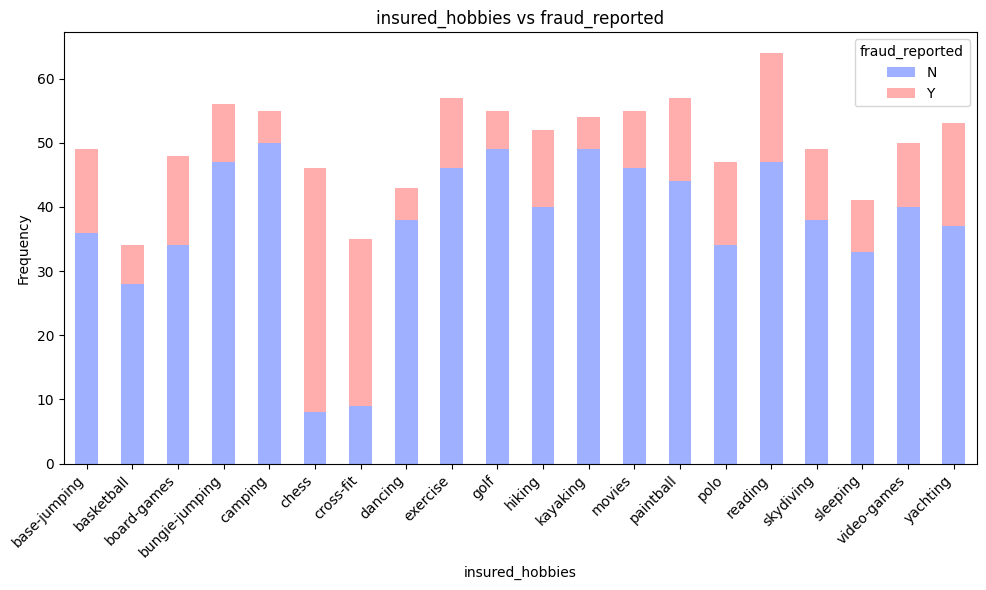

P-Value for insured_hobbies: 0.0
Cramér's V for insured_hobbies: 0.403


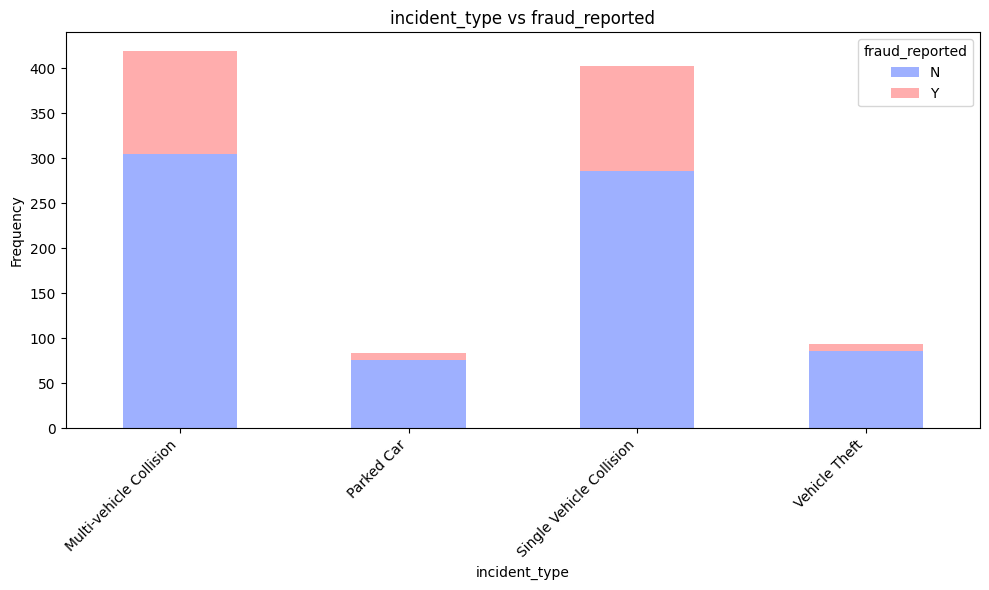

P-Value for incident_type: 0.0
Cramér's V for incident_type: 0.171


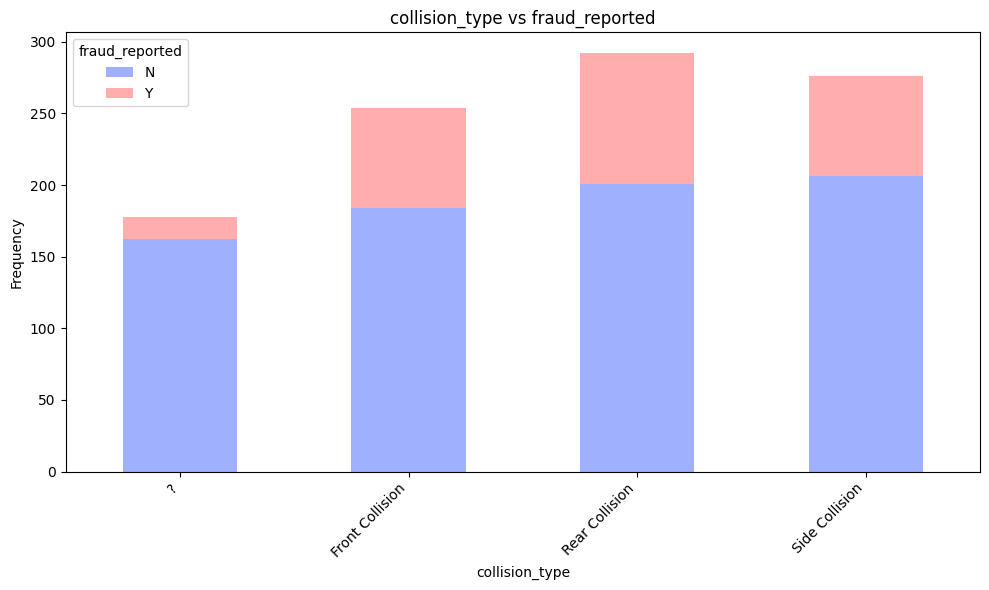

P-Value for collision_type: 0.0
Cramér's V for collision_type: 0.177


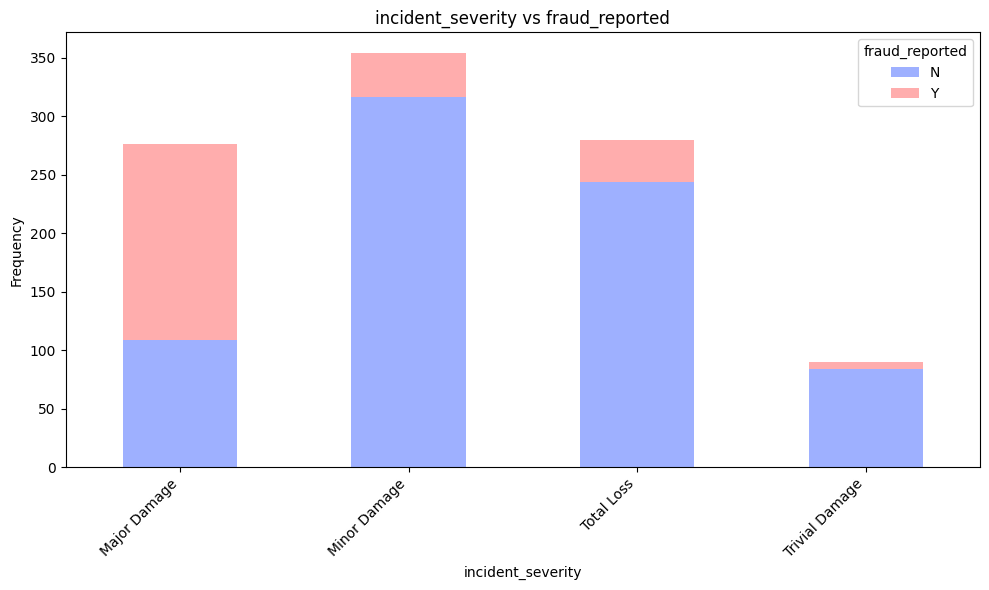

P-Value for incident_severity: 0.0
Cramér's V for incident_severity: 0.514


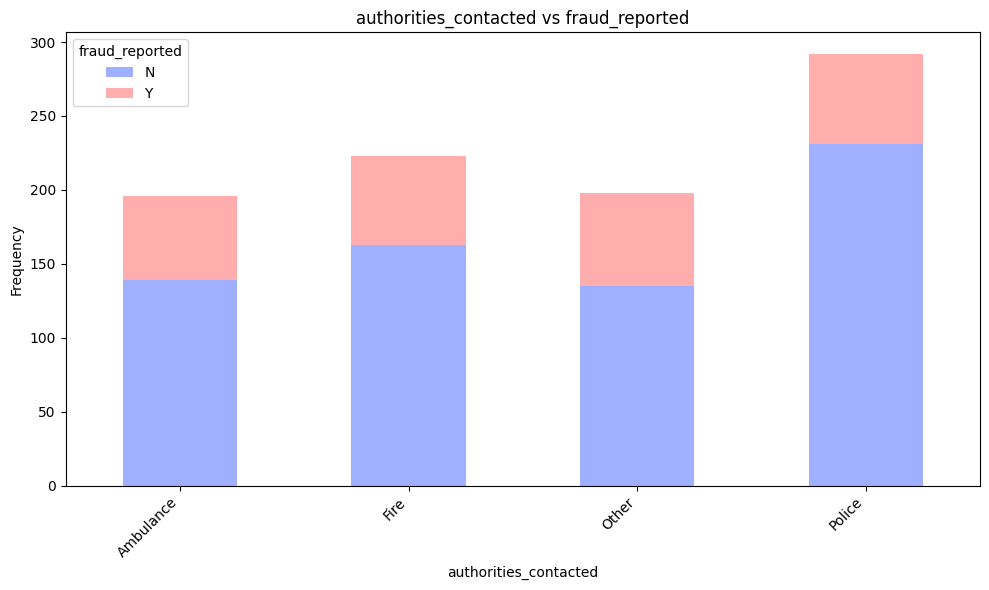

P-Value for authorities_contacted: 0.041
Cramér's V for authorities_contacted: 0.095


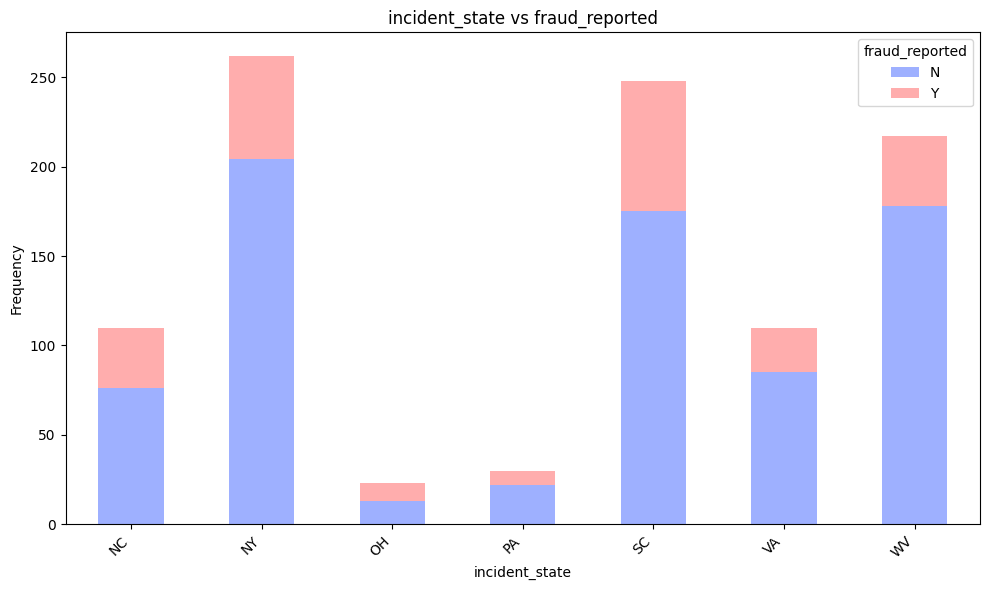

P-Value for incident_state: 0.013
Cramér's V for incident_state: 0.127


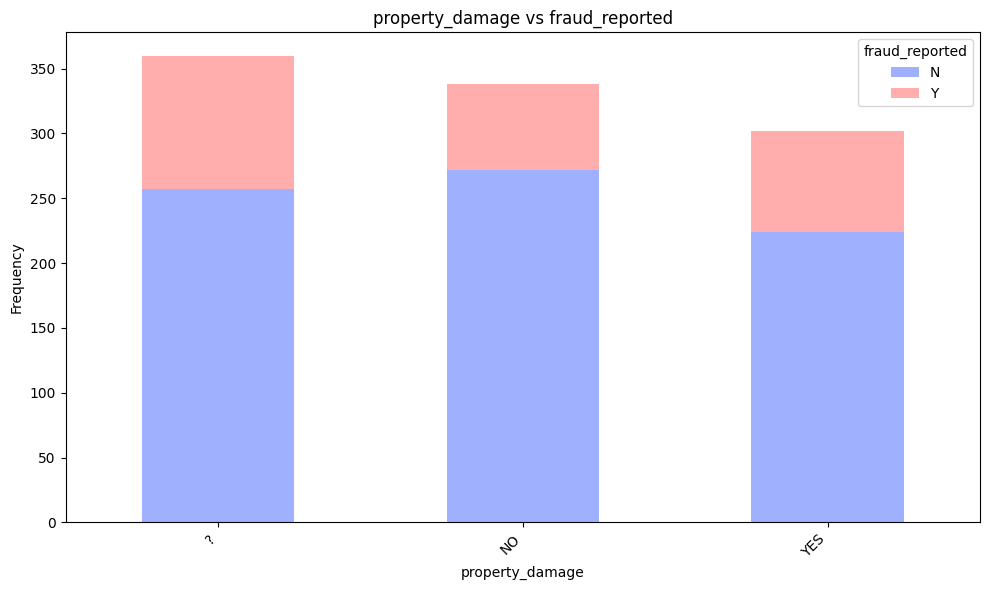

P-Value for property_damage: 0.018
Cramér's V for property_damage: 0.09


In [15]:
import numpy as np
import pandas as pd
from scipy.stats import chi2_contingency
import matplotlib.pyplot as plt
import ipywidgets as widgets
from ipywidgets import Textarea, VBox
from IPython.display import display


# Create a function to plot the data
def plot_categorical_with_notes(df, col, target_col):
    # Create a contingency table
    contingency_table = pd.crosstab(df[col], df[target_col])
    
    # Perform chi-squared test
    chi2, p, dof, ex = chi2_contingency(contingency_table)
    
    # Calculate Cramér's V
    n = contingency_table.sum().sum()
    cramer_v = np.sqrt(chi2 / (n * (min(contingency_table.shape) - 1)))
    
    # Plot the contingency table
    ax = contingency_table.plot(kind='bar', stacked=True, colormap='berlin', figsize=(10, 6))
    plt.title(f'{col} vs {target_col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
    
    # Display statistical information
    print(f'P-Value for {col}: {round(p, 3)}')
    print(f'Cramér\'s V for {col}: {round(cramer_v, 3)}')
    
    # Create a text area for notes
    notes = Textarea(
        value='',
        placeholder='Enter your notes here...',
        description='Notes:',
        layout={'width': '100%', 'height': '100px'}
    )
    display(VBox([notes])) 

# Example usage
plot_categorical_with_notes(df, 'insured_hobbies', 'fraud_reported')            # plot for column 'insured_occupationplot_categorical(df, 'insured_relationship', 'fraud_reported')      # plot for column 'insured_relationship'
plot_categorical_with_notes(df, 'incident_type', 'fraud_reported')             # plot for column 'incident_type'
plot_categorical_with_notes(df, 'collision_type', 'fraud_reported')            # plot for column 'collision_type'
plot_categorical_with_notes(df, 'incident_severity', 'fraud_reported')         # plot for column 'incident_severity'
plot_categorical_with_notes(df, 'authorities_contacted', 'fraud_reported')     # plot for column 'authorities_contacted'
plot_categorical_with_notes(df, 'incident_state', 'fraud_reported')            # plot for column 'incident_state'
plot_categorical_with_notes(df, 'property_damage', 'fraud_reported')           # plot for column 'property_damage'

In [16]:
# filter on collision_type euqals ? with loc 
df.loc[df['collision_type']=='?']

,months_as_customer,age,policy_number,policy_bind_date,policy_state,policy_csl,policy_deductable,policy_annual_premium,umbrella_limit,insured_zip,...,auto_make,auto_model,auto_year,fraud_reported,policy_bind_year,policy_bind_month,policy_bind_weekday,incident_month,incident_weekday,incident_location_class
1,228,42,342868,2006-06-27,IN,250/500,2000,1197.22,5000000,468176,...,Mercedes,E400,2007,Y,2006,6,1,1,2,66
4,228,44,367455,2014-06-06,IL,500/1000,1000,1583.91,6000000,610706,...,Accura,RSX,2009,N,2014,6,4,2,1,30
13,121,34,626808,2012-10-26,OH,100/300,1000,936.61,0,464652,...,Toyota,Highlander,2010,N,2012,10,4,1,3,65
26,257,43,863236,1990-09-20,IN,100/300,2000,1322.10,0,436984,...,Toyota,Camry,2005,N,1990,9,3,1,2,25
27,202,34,608513,2002-07-18,IN,100/300,500,848.07,3000000,607730,...,Suburu,Forrestor,2003,Y,2002,7,3,1,2,37
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
964,163,37,390256,2009-11-25,IN,500/1000,1000,1200.33,4000000,477631,...,Volkswagen,Jetta,2008,Y,2009,11,2,2,4,67
969,398,55,844062,1990-05-25,OH,250/500,500,862.19,0,606858,...,Accura,MDX,2012,N,1990,5,4,2,0,81
983,17,39,774895,2006-10-28,IL,250/500,1000,840.95,0,431202,...,Suburu,Legacy,2002,N,2006,10,5,2,3,70
994,141,30,681486,2007-03-24,IN,500/1000,1000,1347.04,0,430665,...,Honda,Civic,1996,N,2007,3,5,1,3,65


In [17]:
#property_damage is '?'
df.loc[df['property_damage']=='?']

,months_as_customer,age,policy_number,policy_bind_date,policy_state,policy_csl,policy_deductable,policy_annual_premium,umbrella_limit,insured_zip,...,auto_make,auto_model,auto_year,fraud_reported,policy_bind_year,policy_bind_month,policy_bind_weekday,incident_month,incident_weekday,incident_location_class
1,228,42,342868,2006-06-27,IN,250/500,2000,1197.22,5000000,468176,...,Mercedes,E400,2007,Y,2006,6,1,1,2,66
3,256,41,227811,1990-05-25,IL,250/500,2000,1415.74,6000000,608117,...,Chevrolet,Tahoe,2014,Y,1990,5,4,1,5,69
6,137,34,413978,2000-06-04,IN,250/500,1000,1333.35,0,441716,...,Nissan,Pathfinder,2012,N,2000,6,6,1,1,58
7,165,37,429027,1990-02-03,IL,100/300,1000,1137.03,0,603195,...,Audi,A5,2015,N,1990,2,5,2,4,35
16,70,26,558938,2005-06-08,OH,500/1000,1000,1199.44,5000000,619884,...,Nissan,Maxima,2012,N,2005,6,2,2,6,50
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
993,124,28,674570,2001-12-08,OH,250/500,1000,1235.14,0,443567,...,Volkswagen,Passat,2012,N,2001,12,5,2,1,16
994,141,30,681486,2007-03-24,IN,500/1000,1000,1347.04,0,430665,...,Honda,Civic,1996,N,2007,3,5,1,3,65
997,130,34,918516,2003-02-17,OH,250/500,500,1383.49,3000000,442797,...,Suburu,Impreza,1996,N,2003,2,0,1,4,76
998,458,62,533940,2011-11-18,IL,500/1000,2000,1356.92,5000000,441714,...,Audi,A5,1998,N,2011,11,4,2,3,61


In [18]:
#missing values per row descending
df.isnull().sum(axis=1).sort_values(ascending=False)

13     1
994    1
953    1
37     1
940    1
      ..
988    0
989    0
990    0
975    0
976    0
Length: 1000, dtype: int64

In [19]:
#CROSSTAB P-value < 5% vs target

p_value_cols = chi2test_results[chi2test_results['p'] < 0.05]['column']

for var in p_value_cols:
    print(pd.crosstab(index=df[var], columns=df['fraud_reported'], normalize='index'))
    print('----------------------')

fraud_reported          N         Y
insured_hobbies                    
base-jumping     0.734694  0.265306
basketball       0.823529  0.176471
board-games      0.708333  0.291667
bungie-jumping   0.839286  0.160714
camping          0.909091  0.090909
chess            0.173913  0.826087
cross-fit        0.257143  0.742857
dancing          0.883721  0.116279
exercise         0.807018  0.192982
golf             0.890909  0.109091
hiking           0.769231  0.230769
kayaking         0.907407  0.092593
movies           0.836364  0.163636
paintball        0.771930  0.228070
polo             0.723404  0.276596
reading          0.734375  0.265625
skydiving        0.775510  0.224490
sleeping         0.804878  0.195122
video-games      0.800000  0.200000
yachting         0.698113  0.301887
----------------------
fraud_reported                   N         Y
incident_type                               
Multi-vehicle Collision   0.727924  0.272076
Parked Car                0.904762  0.095238
Singl